In [1]:
!pip install mglearn scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 5.5 MB/s eta 0:00:00


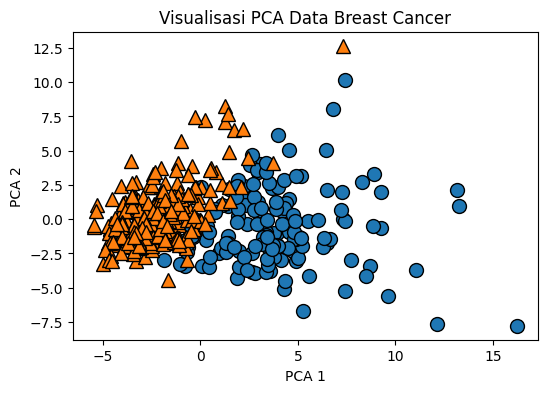

Hasil Cluster KMeans (10 sampel pertama) : [0 1 0 1 1 0 0 0 0 0]
Hasil Cluster DBSCAN (10 sampel pertama) : [ 0 -1 -1 -1 -1 -1  0  0 -1 -1]


In [2]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6, 4))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], y_train)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi PCA Data Breast Cancer")
plt.show()

kmeans = KMeans(n_clusters=2, random_state=0)
pred_kmeans = kmeans.fit_predict(X_train_scaled)

dbscan = DBSCAN(eps=2.0, min_samples=5)
pred_db = dbscan.fit_predict(X_train_scaled)

print("Hasil Cluster KMeans (10 sampel pertama) :", pred_kmeans[:10])
print("Hasil Cluster DBSCAN (10 sampel pertama) :", pred_db[:10])